#  Analyzing and Making Predictions of Tech Stocks
In this project, I will use pandas to analyze data, including value, risk and return metrics, of the prominent 'FAANG' companies: Facebook, Apple, Amazon, Netflix, and Google. Here are some of the questions I'll address in this notebook:


What was the change in our stock’s price over time?
What was the moving average of our stocks?
What was the daily return average of a stock?
What was the correlation between daily returns of different stocks?
How much value do we put at risk by investing in a particular stock?
How can we attempt to predict future 'FAANG'-stock behavior?

In [38]:
from __future__ import division
import pandas as pd
from pandas import Series,DataFrame
import numpy as np

#Visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


from datetime import datetime
#Using yfinance to access Yahoo Historical Stocks
import yfinance as yf

I will be comparing the five "FAANG" companies to analyze their average stock prices and returns to ultimately perform a risk assessment of the stocks in the last 365 days. 

In [39]:
stock_list = ['AAPL','GOOG','MSFT','AMZN','NFLX']

end = datetime.now()

#Start date set to 1 year back
start = datetime(end.year-1,end.month,end.day) 

for stock in stock_list:
    globals()[stock] = yf.download(stock,start,end) 

C:\Users\HP\AppData\Local\Temp\ipykernel_3996\8645532.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed
C:\Users\HP\AppData\Local\Temp\ipykernel_3996\8645532.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed
C:\Users\HP\AppData\Local\Temp\ipykernel_3996\8645532.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed
C:\Users\HP\AppData\Local\Temp\ipykernel_3996\8645532.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock,start,end)
[*********************100%***************

Here I've listed simple statistics regarding the stock price of Netflix in the previous year.

In [40]:
NFLX.head(3)

Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,
2024-09-03,675.320007,703.859985,671.010010,700.099976,3161000
2024-09-04,679.679993,684.650024,673.059998,673.309998,1785300
2024-09-05,683.619995,687.309998,671.859985,673.140015,1810100


In [41]:
NFLX.describe()

Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,989.734598,1001.398040,976.314160,988.610680,3.741441e+06
std,188.556650,189.536617,186.504081,188.339323,1.937098e+06
min,665.770020,680.590027,660.799988,673.140015,1.664500e+06
25%,865.862518,881.030014,852.565002,861.602524,2.509975e+06
50%,971.860016,983.485016,952.725006,971.354980,3.213450e+06
75%,1183.339966,1191.592499,1173.127472,1182.832458,4.194825e+06
max,1339.130005,1341.150024,1321.209961,1338.229980,1.597410e+07


In [42]:
NFLX.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2024-09-03 to 2025-09-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NFLX)   250 non-null    float64
 1   (High, NFLX)    250 non-null    float64
 2   (Low, NFLX)     250 non-null    float64
 3   (Open, NFLX)    250 non-null    float64
 4   (Volume, NFLX)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


## Change in Stock Price Over Time

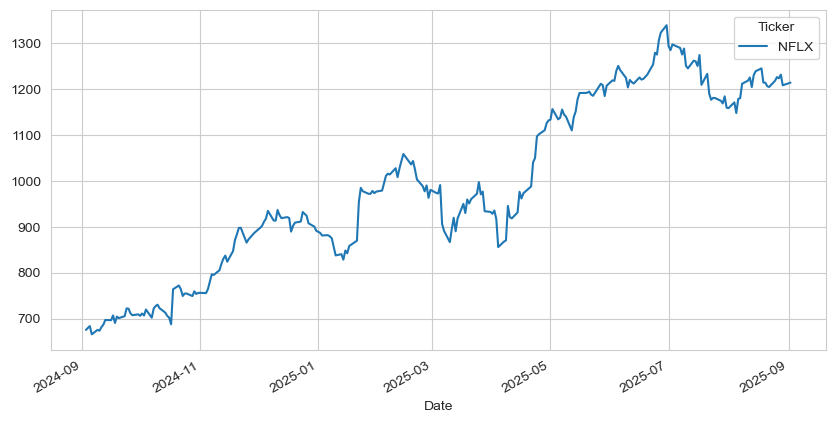

In [45]:
NFLX["Close"].plot(legend=True, figsize=(10,5))
plt.show()


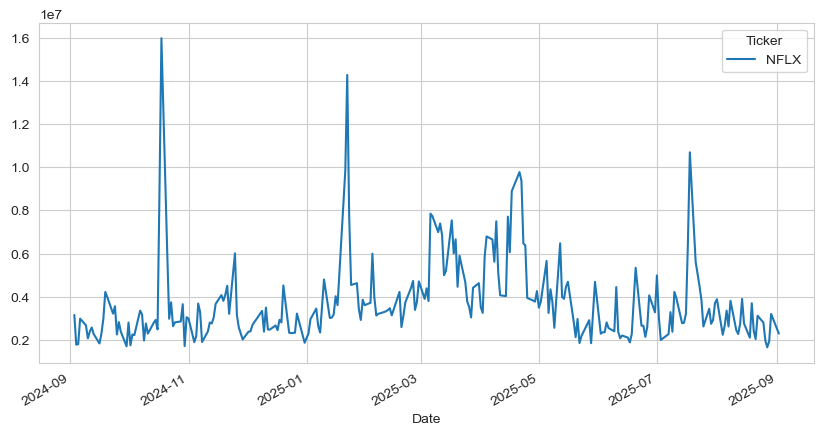

In [46]:
NFLX['Volume'].plot(legend = True, figsize = (10,5))
plt.show()


Combined Analysis of Price and Volume
1. Late 2024 (September - November): Steady Growth
 * Price: The stock price shows a steady, gradual increase from around $700 to just under $800.
 * Volume: Trading volume is relatively low and consistent during this period, without any major spikes.
 * Correlation: The modest price increase is not driven by a sudden rush of investor activity but by a more sustained, underlying interest, likely supported by positive company news from the previous quarters. This suggests a period of stable and healthy growth.
2. Early 2025 (Late January): The First Major Spike
 * Price: The price graph shows a sharp, strong upward move in late January.
 * Volume: The volume graph shows a massive, unprecedented spike at the same time. This is the highest volume seen throughout the entire year.
 * Correlation: This significant price increase on extremely high volume is a classic indicator of a major market event. This aligns with the reporting of Netflix's Q4 2024 earnings, which showed a record number of new subscribers and a strong increase in revenue and earnings per share. This positive report caused a flood of buying, pushing the stock to a new all-time high.
3. Mid-2025 (March - April): The Second Major Spike
 * Price: Following a dip in the stock price, there is a second major upward move, though not as dramatic as the first.
 * Volume: The volume graph shows another significant spike, the second highest of the year, corresponding with this price jump.
 * Correlation: This high volume and price movement likely correspond to the release of Netflix's Q1 2025 earnings. The company reported impressive results, including higher-than-expected revenue and earnings, fueled by recent price increases and the growth of its ad-supported tier. This news once again renewed investor optimism.
4. Mid-2025 (June - July): The Peak and Pullback
 * Price: The stock price reaches its peak above $1300 in June and then experiences a sharp, sustained decline.
 * Volume: Trading volume is elevated during this period, especially during the drop.
 * Correlation: The high volume during the price decline indicates that a large number of shares are being sold. This "profit-taking" from investors, who have seen the stock's massive run-up, is a common occurrence. The decline could also be influenced by analyst downgrades or a general market correction, as investors reassess their positions after a period of rapid growth.
5. Late 2025 (August - September): Consolidation
 * Price: The stock price stabilizes in the $1100-$1200 range.
 * Volume: Trading volume returns to a more average, consistent level.
 * Correlation: The drop in both price volatility and trading volume suggests the market has digested the recent gains and subsequent correction. The stock is entering a new phase of consolidation as investors evaluate its long-term potential at this new, higher price level.


## Calculating Moving Averages

In [47]:
averages = [10,25,50]
for avg in averages:
    label = "MAvg for %s days" %(str(avg))
    NFLX[label] = NFLX['Close'].rolling(window = avg, center = False).mean()

In [48]:
NFLX.tail()

Price,Close,High,Low,Open,Volume,MAvg for 10 days,MAvg for 25 days,MAvg for 50 days
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX,,,
Date,,,,,,,,
2025-08-26,1226.089966,1231.500000,1212.199951,1220.209961,1985700,1220.206982,1196.743193,1229.979202
2025-08-27,1223.500000,1229.209961,1213.000000,1223.609985,1664500,1222.112988,1198.611992,1229.942202
2025-08-28,1231.449951,1237.890015,1214.270020,1222.790039,1950300,1222.201978,1200.639590,1230.157800
2025-08-29,1208.250000,1228.790039,1201.150024,1227.969971,3209800,1219.131982,1201.749990,1229.877000
2025-09-02,1214.109985,1215.400024,1182.800049,1197.000000,2299100,1216.033984,1203.330391,1229.530999


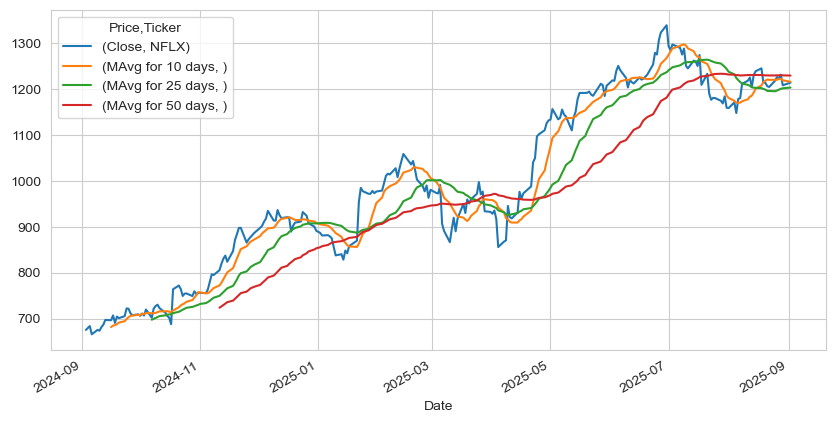

In [49]:
NFLX[[ 'Close', 'MAvg for 10 days', 'MAvg for 25 days', 'MAvg for 50 days']].plot(subplots = False, figsize = (10,5))
plt.show()


​"The provided graph shows Netflix's stock (NFLX) and its moving averages over time. The 50-day moving average (red line) smooths out short-term fluctuations and helps us identify the long-term trend. The graph clearly shows the stock price is trading in the range of approximately $650 to $1,300
 when the 10-day moving average (green line) or the 25-day moving average (maroon line) crosses above the 50-day moving average, it's a bullish signal that suggests an upward trend is forming. Conversely, when the shorter-term averages cross below the 50-day average, it can be a bearish signal, indicating a potential decline. Observing these crossovers can help us understand when the stock's trend is changing direction."

## Daily Return Averages.


In [50]:
#The daily return column can be created by using the percentage change over the adjusted closing price
NFLX['Daily Return'] = NFLX['Close'].pct_change()
NFLX.tail()

Price,Close,High,Low,Open,Volume,MAvg for 10 days,MAvg for 25 days,MAvg for 50 days,Daily Return
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX,,,,
Date,,,,,,,,,
2025-08-26,1226.089966,1231.500000,1212.199951,1220.209961,1985700,1220.206982,1196.743193,1229.979202,0.006584
2025-08-27,1223.500000,1229.209961,1213.000000,1223.609985,1664500,1222.112988,1198.611992,1229.942202,-0.002112
2025-08-28,1231.449951,1237.890015,1214.270020,1222.790039,1950300,1222.201978,1200.639590,1230.157800,0.006498
2025-08-29,1208.250000,1228.790039,1201.150024,1227.969971,3209800,1219.131982,1201.749990,1229.877000,-0.018840
2025-09-02,1214.109985,1215.400024,1182.800049,1197.000000,2299100,1216.033984,1203.330391,1229.530999,0.004850


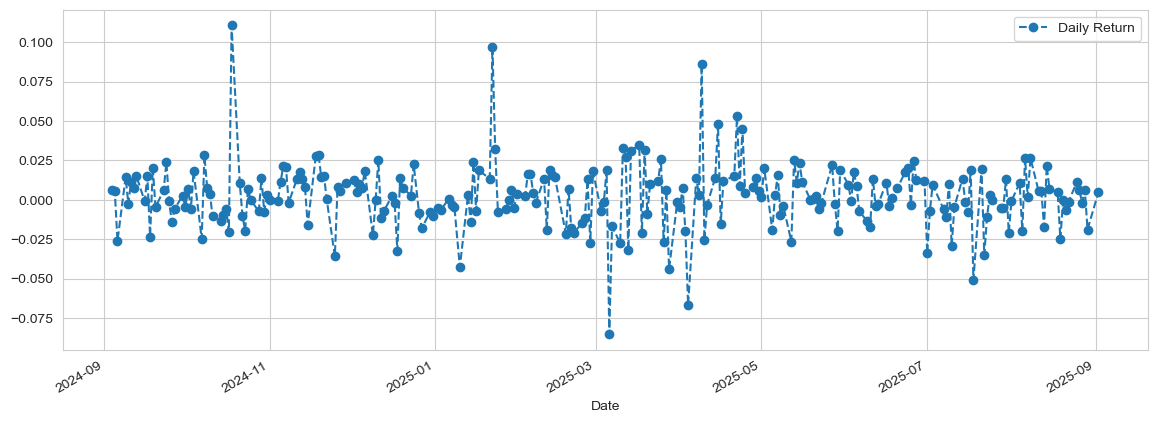

In [51]:
NFLX['Daily Return'].plot(figsize=(14,5),legend=True,linestyle='--',marker='o')
plt.show()

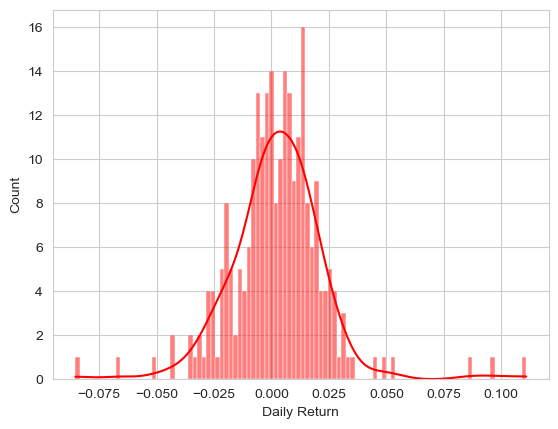

In [52]:
sns.histplot(NFLX['Daily Return'].dropna(),bins=100,color='red',kde=True)
plt.show()

Using Seaborn to plot our axes, we find that the distribution of daily returns is concentrated heavily around 0 with little skew toward positive or negative returns it follows normal distribution.

## Correlation Between Different Daily Stock Returns

Now let's examine the trend between some pairs of the 'FAANG' stocks using Seaborn's joint plot feature, using the percent change of daily returns.

In [53]:
close_compr = yf.download(stock_list,start,end)['Close']
rets_compr = close_compr.pct_change()
rets_compr.tail()

C:\Users\HP\AppData\Local\Temp\ipykernel_3996\4045337843.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  close_compr = yf.download(stock_list,start,end)['Close']
[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOG,MSFT,NFLX
Date,,,,,
2025-08-26,0.009465,0.003378,-0.005785,-0.004402,0.006584
2025-08-27,0.005146,0.001793,0.001250,0.009362,-0.002112
2025-08-28,0.008981,0.010824,0.019980,0.005723,0.006498
2025-08-29,-0.001806,-0.011226,0.005462,-0.005788,-0.018840
2025-09-02,-0.010425,-0.015983,-0.007212,-0.003099,0.004850


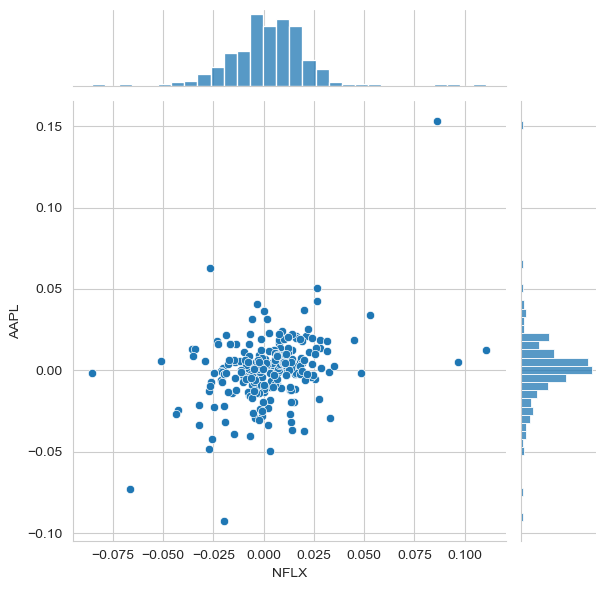

In [54]:
sns.jointplot(x='NFLX', y='AAPL', data=rets_compr, kind='scatter')
plt.show()

There seems to be a weak correlation between Netflix and Apple returns. I'll generate all of the pairwise plots to see if there are any stronger correlations.

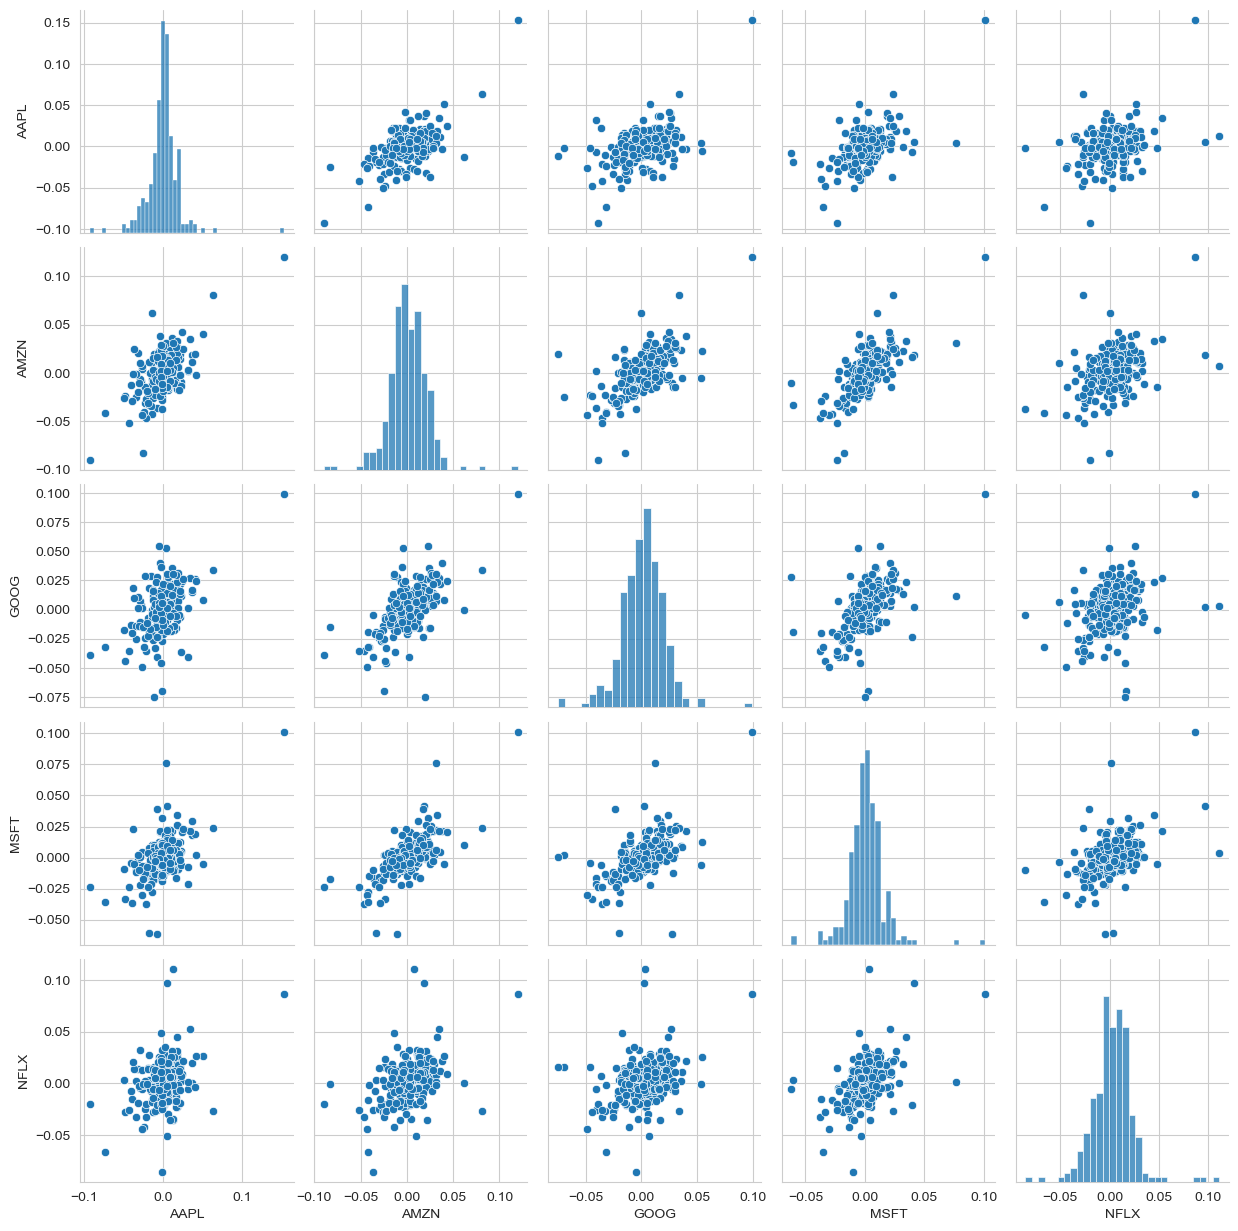

In [55]:
sns.pairplot(rets_compr.dropna())
plt.show()

There seems to be stronger correlations between Amazon and Microsoft, though to be sure we need another visualization tool. The correlation matrix plot, which allows us to view the pairwise confidence intervals together, is a great option for doing this.

Ticker      AAPL      AMZN      GOOG      MSFT      NFLX
Ticker                                                  
AAPL    1.000000  0.603699  0.492771  0.538909  0.355374
AMZN    0.603699  1.000000  0.628760  0.684428  0.438598
GOOG    0.492771  0.628760  1.000000  0.533226  0.347856
MSFT    0.538909  0.684428  0.533226  1.000000  0.475299
NFLX    0.355374  0.438598  0.347856  0.475299  1.000000


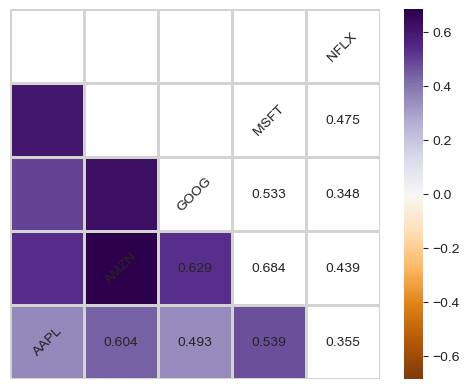

In [56]:
corr = rets_compr.corr()
print(corr)
# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
fig, ax = plt.subplots()

# Draw the heatmap with the mask and correct aspect ratio
vmax = np.abs(corr.values[~mask]).max()
sns.heatmap(corr, mask=mask, cmap=plt.cm.PuOr, vmin=-vmax, vmax=vmax,
            square=True, linecolor="lightgray", linewidths=1, ax=ax)
for i in range(len(corr)):
    ax.text(i+0.5,len(corr)-(i+0.5), corr.columns[i], 
            ha="center", va="center", rotation=45)
    for j in range(i+1, len(corr)):
        s = "{:.3f}".format(corr.values[i,j])
        ax.text(j+0.5,len(corr)-(i+0.5),s, 
            ha="center", va="center")
ax.axis("off")
plt.show()

From the correlation heatmap, it becomes clear that Microsoft and Amazon share a stronger correlation, and in general
Microsoft maintains a strongest pairwise aggregate correlations compared to the rest of the 'FAANG' companies. Though perhaps expected, it is noteworthy that all five companies pairwise have moderate to strong positive correlation.

## Determining Value from Risk vs. Expected Return
Now we address the question of risk in buying stocks to compare these five companies.

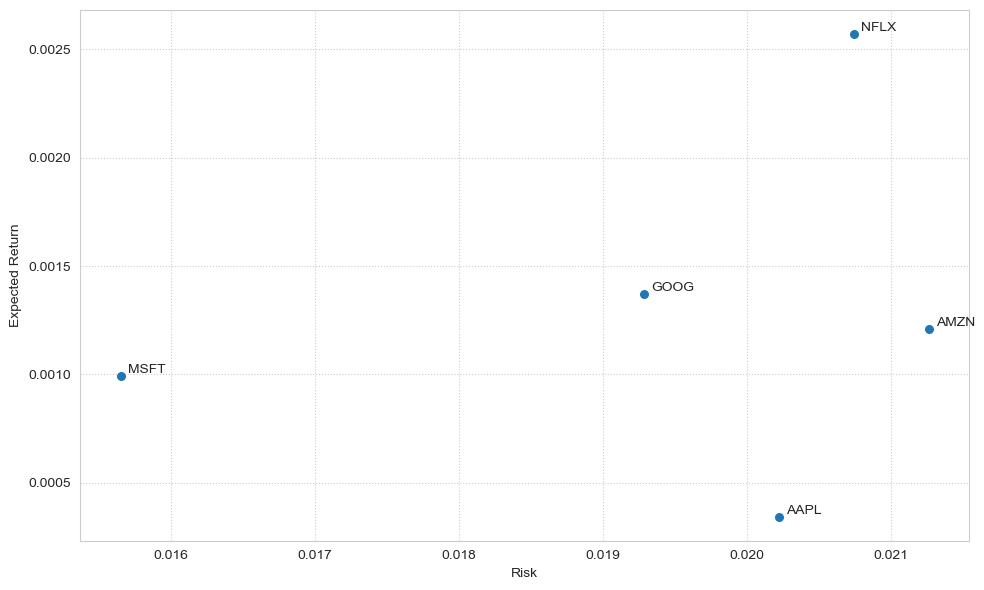

In [73]:


rets_filled = rets_compr.dropna()
plt.figure(figsize=(10,6))
plt.scatter(rets_filled.std(), rets_filled.mean(), s=30)

plt.xlabel('Risk')
plt.ylabel('Expected Return')
plt.grid(True, linestyle=':', linewidth=0.8)

for label, x, y in zip(rets_filled.columns, rets_filled.std(), rets_filled.mean()):
    plt.annotate(
        label, (x, y),
        textcoords='offset points',
        xytext=(5, 2),
        ha='left',
        fontsize=10
    )

plt.tight_layout()
plt.show()


Risk-Return Plot: The risk-return scatter plot visualizes each stock's expected return against its risk (volatility). The plot confirms the financial principle that higher returns often come with higher risk. MSFT is positioned at the low end for both risk and return, while NFLX sits at the high end, reflecting its reputation as a more volatile growth stock. This plot also highlights that for a similar level of risk, AMZN has historically offered a higher expected return than AAPL, making it appear more attractive to a risk-averse investor.

We want to model an additional value-at-risk metric in order to assess the value at each risk confidence interval for these 5 companies. Let's try this two ways: bootstrapping and using Monte Carlo-GBM, with Google.

In [62]:
rets_compr.head()

Ticker,AAPL,AMZN,GOOG,MSFT,NFLX
Date,,,,,
2024-09-03,NaN,NaN,NaN,NaN,NaN
2024-09-04,-0.008619,-0.016567,-0.005044,-0.001319,0.006456
2024-09-05,0.006928,0.026308,0.005006,-0.001247,0.005797
2024-09-06,-0.007015,-0.036539,-0.040794,-0.016381,-0.026111
2024-09-09,0.000408,0.023397,-0.015731,0.010007,0.014494


In [79]:
rets_compr['GOOG'].quantile(q=0.05)*100


-3.198999532205708

In [80]:
rets_compr['GOOG'].quantile(q=0.01)*100



-4.731501062731263

From the empirical quantiles given for both confience intervals, we know that the worst possible loss will not exceed 3.19 percent with 95% confidence and 4.73 percent with 99% confidence.

## Predicting Future Risk and Value of Stocks
We run the Monte Carlo Method on the GBM model to assess the stability and predict the future risk of our stocks. For this component, I'll be analyzing Google's stock.

In [65]:
days = 365

#delta t
dt = 1/365

mu = rets_compr.mean()['GOOG']

sigma = rets_compr.std()['GOOG']


def stock_monte_carlo(start_price,days,mu,sigma):
    
    price = np.zeros(days)
    price[0] = start_price
    
    shock = np.zeros(days)
    drift = np.zeros(days)
    
    for x in range(1,days):
        
        #Shock and drift formulas taken from the Monte Carlo formula
        shock[x] = np.random.normal(loc=mu*dt,scale=sigma*np.sqrt(dt))
        
        drift[x] = mu * dt
        
        #New price = Old price + Old price*(shock+drift)
        price[x] = price[x-1] + (price[x-1] * (drift[x]+shock[x]))
        
    return price

We’re going to run 100 Monte Carlo simulations of Google stocks. Here's the stock's opening values again.



In [66]:
GOOG.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2024-09-03,157.852203,162.599418,157.100806,162.534726,26533100
2024-09-04,157.056015,159.633637,156.687788,157.319748,17410700
2024-09-05,157.842239,160.245694,156.767398,157.026150,14139500
2024-09-06,151.403152,158.459274,151.209077,157.931807,24999100
2024-09-09,149.021439,154.103760,147.686089,153.097267,28057700


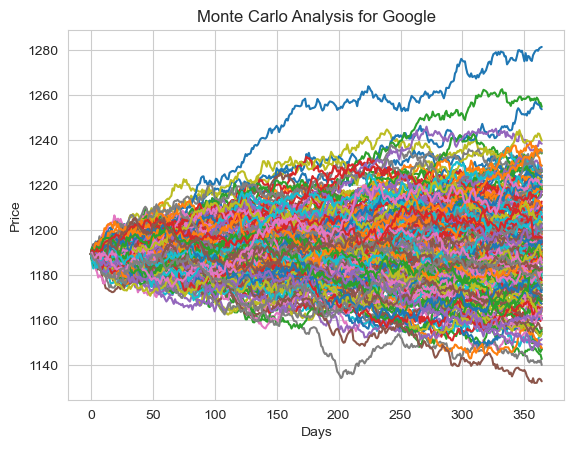

In [68]:
start_price = 1189.39 #Taken from above

for run in range(1,100):
    plt.plot(stock_monte_carlo(start_price,days,mu,sigma))

plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Analysis for Google')
plt.show()

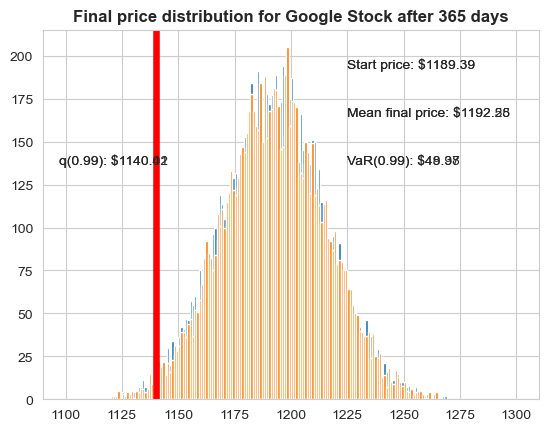

In [70]:
runs = 10000

simulations = np.zeros(runs)

for run in range(1,runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]
q = np.percentile(simulations,1)

plt.hist(simulations,bins=200,range = [1100,1300])

plt.figtext(0.6,0.8,s="Start price: $%.2f" %start_price)

plt.figtext(0.6,0.7,"Mean final price: $%.2f" % simulations.mean())

plt.figtext(0.6,0.6,"VaR(0.99): $%.2f" % (start_price -q,))

plt.figtext(0.15,0.6, "q(0.99): $%.2f" % q)

plt.axvline(x=q, linewidth=4, color='r')

plt.title(u"Final price distribution for Google Stock after %s days" %days, weight='bold')
plt.show()

Based off the histogram, we conclude that Google's stock price is very stable (only a $2.89 difference between start and mean final price). The value-at-risk of our investment is $49.93 for maximum low price of $1140.92 with 99% confidence, which is approximately  4.37% risk compared to the 3.19% we achieved via bootstrapping. 

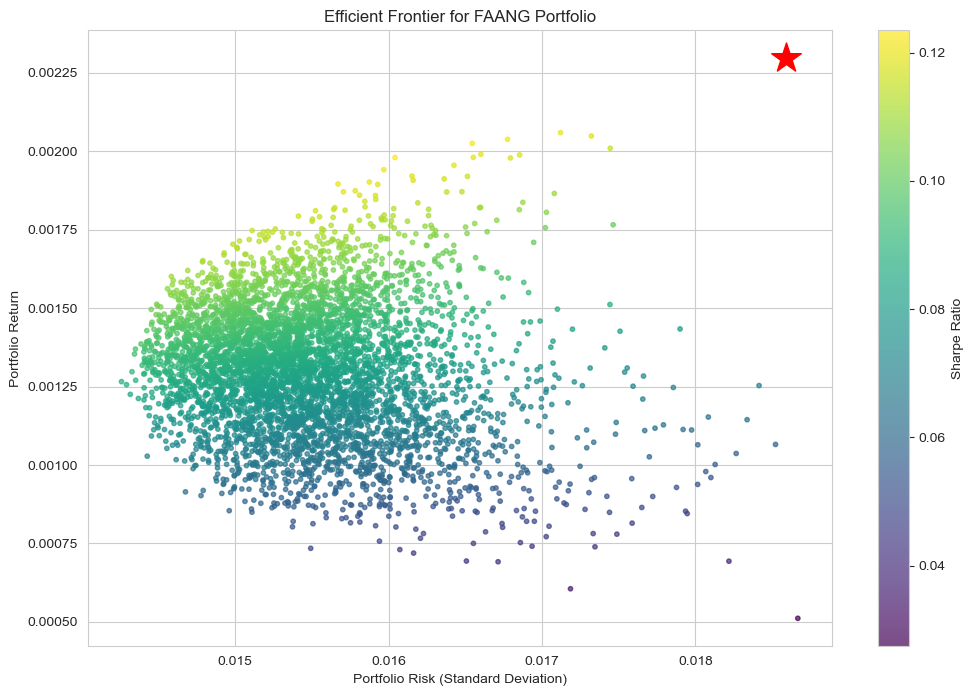

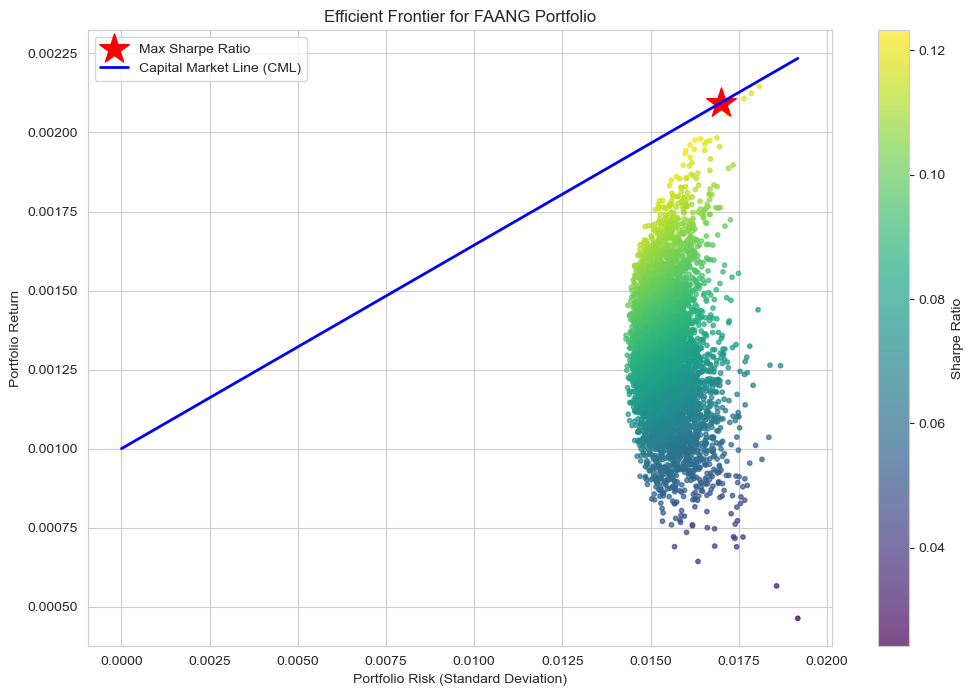

In [85]:
# Efficient Frontier and Capital Market Line for FAANG Portfolio

# Number of portfolios to simulate
num_portfolios = 5000

# Arrays to store results
results = np.zeros((3, num_portfolios))
weights_record = []

# Use mean returns and covariance matrix from rets_compr and cov_matrix
mean_returns = rets_compr.mean()
cov_matrix = rets_compr.cov()
risk_free_rate = 0.0  # You can adjust this if needed

for i in range(num_portfolios):
    weights = np.random.random(len(stock_list))
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_stddev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_stddev
    
    results[0,i] = portfolio_stddev
    results[1,i] = portfolio_return
    results[2,i] = sharpe_ratio

# Find the portfolio with the maximum Sharpe ratio
max_sharpe_idx = np.argmax(results[2])
max_sharpe_std = results[0, max_sharpe_idx]
max_sharpe_ret = results[1, max_sharpe_idx]

# Plot Efficient Frontier
plt.figure(figsize=(12,8))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.title('Efficient Frontier for FAANG Portfolio')

# Mark the maximum Sharpe ratio portfolio
plt.scatter(max_sharpe_std, max_sharpe_ret, marker='*', color='r', s=500, label='Max Sharpe Ratio')
risk_free_rate=0.001

# Capital Market Line (CML)
cml_x = np.linspace(0, results[0,:].max(), 100)
cml_y = risk_free_rate +((max_sharpe_ret - risk_free_rate) / max_sharpe_std) * cml_x
plt.plot(cml_x, cml_y, color='blue', linewidth=2, label='Capital Market Line (CML)')

plt.legend()
plt.show()